testailen miltä lad voisi näyttää ränskiksessä 2022-2025

ss may 2026

vuoden 2022 lad on suht järkevä, muita ei vielä katottu.

Älä tallenna tän kautta ladprofiilitiedostoja, säädä ne param-tiedostossa suoraan. Se on selkeempi ja kätevämpi ku tekee uudet parametritiedostot jokaiselle vuodelle

In [1]:
import sys
import os
from dotenv import load_dotenv
import pathlib

load_dotenv()

pyAPES_main_folder = pathlib.Path(os.getenv("pyAPES_main_folder")).resolve()
sys.path.insert(0, str(pyAPES_main_folder))

ran_lai_folder = pathlib.Path(os.getenv("FI_ran_lai_folder")).resolve()


In [2]:

# import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib widget

In [3]:
# os.path.isdir(ran_lai_folder) 


## ränskis LAI & ndvi

vuosien välillä on aika isot erot LAIssa

In [4]:
lai_file  = f'{ran_lai_folder}\\ranskalankorpi_luke_clearcut_lai.csv'
ndvi_file  = f'{ran_lai_folder}\\ranskalankorpi_luke_clearcut_ndvi.csv'

lai = pd.read_csv(lai_file, header=0)
ndvi = pd.read_csv(ndvi_file, header=0)

for df in [lai, ndvi]:
    timestamp_col = df.columns[0]
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], format="%Y-%m-%dT%H:%M:%S.%fZ", utc=True, errors='coerce')
    df.dropna(subset=[timestamp_col], inplace=True)
    df.set_index(timestamp_col, inplace=True)
    # df.index = df.index.tz_convert('Europe/Helsinki')
    df.index.names = ['datetime']

# lai

In [5]:
# lai_fil_nc  = f'{ran_lai_folder}\\ranskalankorpi_luke_clearcut_s2_data.nc'
# import xarray as xr
# lai_ds = xr.open_dataset(lai_fil_nc)
# lai_ds

In [14]:
lai.loc[lai.index.year==2022]

,lai,lai_F050,lai_std,lai_se,lai_uncertainty,lai_F005,lai_F095,lai_aoi_nan_percentage
datetime,,,,,,,,
2022-05-22 09:50:41+00:00,0.236460,0.217778,0.077800,0.006752,0.172584,0.000000,0.520361,0.00000
2022-05-24 09:40:29+00:00,0.242878,0.229027,0.076665,0.006654,0.172076,0.000000,0.525943,0.00000
2022-06-24 10:00:41+00:00,0.559256,0.521772,0.160174,0.013902,0.222235,0.193680,0.924832,0.00000
2022-06-26 09:50:39+00:00,0.502237,0.460826,0.188403,0.016352,0.243369,0.101895,0.902578,0.00000
2022-06-28 09:40:41+00:00,0.487634,0.446950,0.163821,0.014218,0.224877,0.117712,0.857557,0.00000
2022-07-03 09:40:39+00:00,0.490828,0.445402,0.174429,0.015139,0.232719,0.108006,0.873650,0.00000
2022-07-04 10:00:41+00:00,0.565787,0.523952,0.161543,0.014021,0.223223,0.198584,0.932989,0.00000
2022-07-21 09:50:41+00:00,0.607645,0.572191,0.161143,0.013986,0.222934,0.240918,0.974372,0.00000
2022-07-31 09:50:41+00:00,0.646421,0.600452,0.179752,0.015601,0.236735,0.256993,1.035850,0.00000


<Axes: xlabel='datetime'>

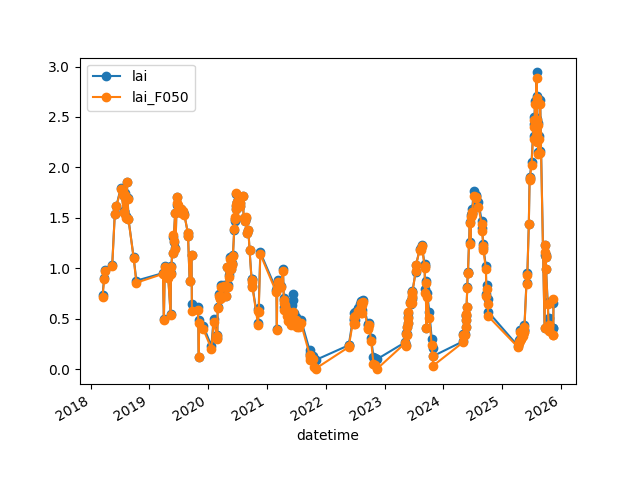

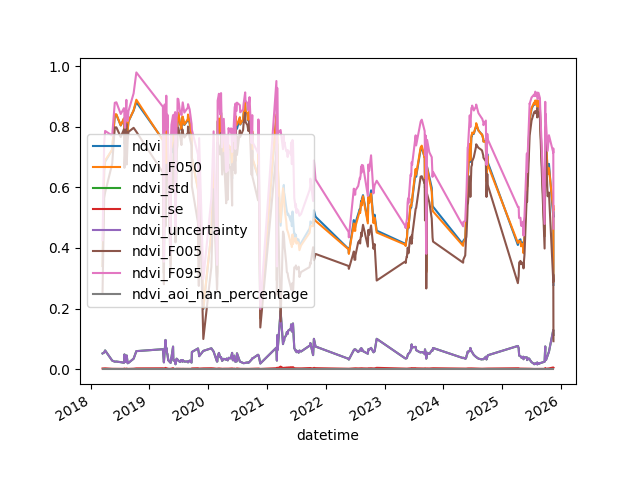

In [13]:
lai[['lai','lai_F050']].plot(marker='o')

ndvi.plot()

when creating param files for FIRan, consider these max LAI values. Most of the interannual LAI increase can be attributed to growth of birches and maybe shrubs

In [7]:
lai['lai_F050'].groupby(lai.index.year).max()

datetime
2018    1.857408
2019    1.706940
2020    1.746757
2021    0.970744
2022    0.666368
2023    1.225098
2024    1.715167
2025    2.882481
Name: lai_F050, dtype: float64

## create LAD

In [8]:
from pyAPES.utils.utilities import lad_weibul, lad_constant

# grid
grid = {'zmax': 5.0,  # heigth of grid from ground surface. Corresponds to height of forcing data [m]
        'Nlayers': 41 # number of layers [-]
        }

z = np.linspace(0, grid['zmax'], grid['Nlayers'])  # grid [m] above ground


### 2022

spruce, decid, shrubs
kaikki on semi matalaa vielä 22, siel on muutama runko pystyssä mut eivät vaikuta paljoa

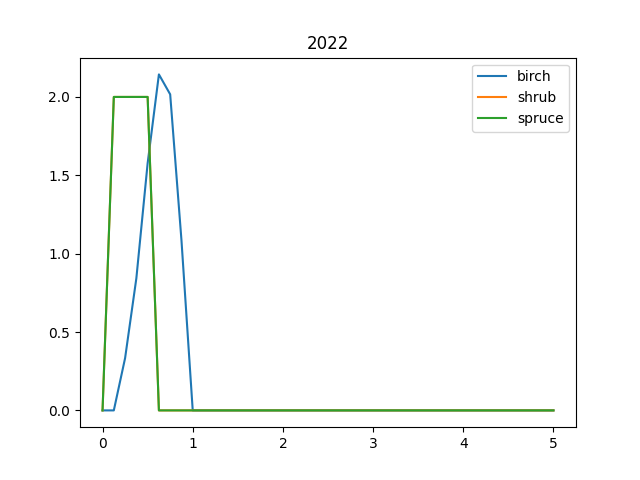

In [9]:

# shrub = lad_constant(z, LAI=1.0, h=0.4, hb=0.0)
# birch = lad_weibul(z, LAI = 1, h=0.4, hb=0.1, species='birch')
# spruce = lad_weibul(z, LAI = 1, h=0.3, hb=0.1, species='spruce')
shrub = lad_constant(z, LAI=1.0, h=0.6, hb=0.0)
birch =  lad_weibul(z, LAI=1.0, h=1.0, hb=0.2, species='generic_deciduous')
spruce = lad_constant(z, LAI=1.0, h=0.6, hb=0.0)  # leaf-area density m2m-3


# lad_const.sum()
# lad_weibul.plot()
plt.figure()
# plt.xlim(-0.1,4)
plt.title('2022')

plt.plot(z, birch, label='birch')
plt.plot(z, shrub, label='shrub')
plt.plot(z, spruce, label='spruce')
plt.legend()

# lad_n = np.column_stack((z, birch, shrub, spruce))
# outfilename = f"{pyAPES_main_folder}\\forcing\\FI-Ran\\ran_lad_prof_norm_2022.dat"
# np.savetxt(outfilename, lad_n, delimiter=';')


### 2023   

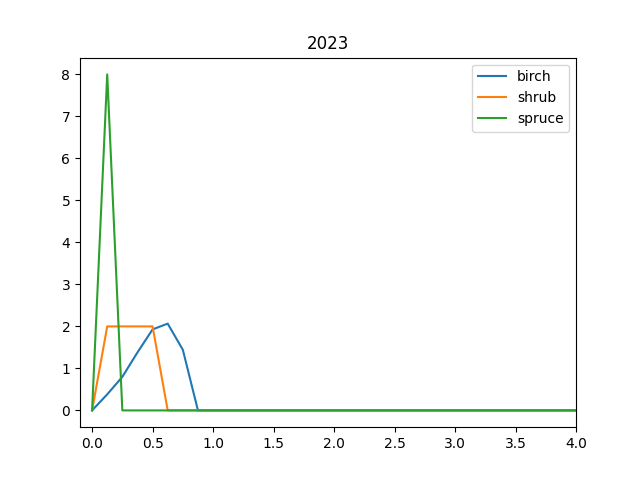

In [10]:

shrub = lad_constant(z, LAI=1.0, h=0.5, hb=0.0)
birch = lad_weibul(z, LAI = 1, h=0.9, hb=0.1, species='birch')
spruce = lad_weibul(z, LAI = 1, h=0.3, hb=0.1, species='spruce')
# lad_const.sum()
# lad_weibul.plot()
plt.figure()
plt.xlim(-0.1,4)
plt.title('2023')
plt.plot(z, birch, label='birch')
plt.plot(z, shrub, label='shrub')
plt.plot(z, spruce, label='spruce')
plt.legend()

# lad_n = np.column_stack((z, birch, shrub, spruce))
# outfilename = f"{pyAPES_main_folder}\\forcing\\FI-Ran\\ran_lad_prof_norm_2023.dat"
# np.savetxt(outfilename, lad_n, delimiter=';')


### 2024

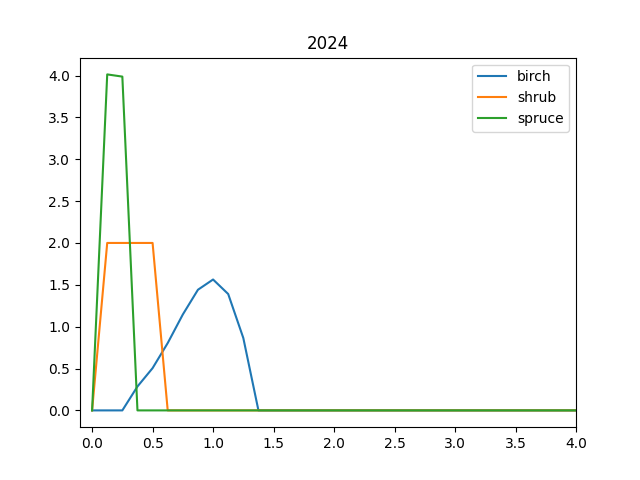

In [11]:
shrub = lad_constant(z, LAI=1.0, h=0.6, hb=0.0)
birch = lad_weibul(z, LAI = 1, h=1.4, hb=0.3, species='birch')
spruce = lad_weibul(z, LAI = 1, h=0.4, hb=0.1, species='spruce')
# lad_const.sum()
# lad_weibul.plot()
plt.figure()
plt.xlim(-0.1,4)
plt.title('2024')

plt.plot(z, birch, label='birch')
plt.plot(z, shrub, label='shrub')
plt.plot(z, spruce, label='spruce')
plt.legend()

# lad_n = np.column_stack((z, birch, shrub, spruce))
# outfilename = f"{pyAPES_main_folder}\\forcing\\FI-Ran\\ran_lad_prof_norm_2024.dat"
# np.savetxt(outfilename, lad_n, delimiter=';')


### 2025

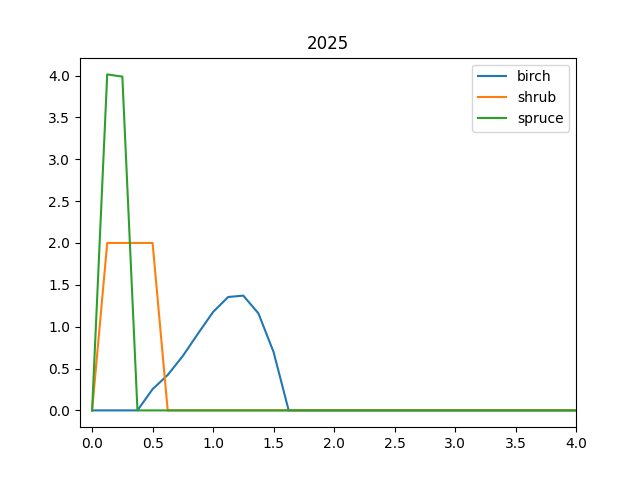

In [12]:
shrub = lad_constant(z, LAI=1.0, h=0.6, hb=0.0)
birch = lad_weibul(z, LAI = 1, h=1.7, hb=0.4, species='birch')
spruce = lad_weibul(z, LAI = 1, h=0.4, hb=0.1, species='spruce')
# lad_const.sum()
# lad_weibul.plot()
plt.figure()
plt.xlim(-0.1,4)
plt.title('2025')
plt.plot(z, birch, label='birch')
plt.plot(z, shrub, label='shrub')
plt.plot(z, spruce, label='spruce')
plt.legend()

# lad_n = np.column_stack((z, birch, shrub, spruce))
# outfilename = f"{pyAPES_main_folder}\\forcing\\FI-Ran\\ran_lad_prof_norm_2025.dat"
# np.savetxt(outfilename, lad_n, delimiter=';')
